# Delivery Time Prediction — Multiple Linear Regression



Classical MLR project: predict food delivery time (minutes) from order,

delivery-partner, and environmental features. Outlier/influence diagnostics

(Cook's Distance, DFFITS), multicollinearity handling (VIF + PCA), model

selection (backward elimination, AIC/BIC/Mallow's Cp/PRESS), and assumption

validation.



Data: real Swiggy delivery dataset, 45,593 rows, India.

### 1. Setup

In [27]:
import pandas as pd

import numpy as np

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.stats.stattools import durbin_watson

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from scipy import stats

import seaborn as sns

import matplotlib.pyplot as plt

In [28]:
# Colab file upload — upload swiggy.csv

from google.colab import files

uploaded = files.upload()

Saving swiggy.csv to swiggy (1).csv


### 2. Load data

In [29]:
df = pd.read_csv("swiggy.csv")

df.columns = df.columns.str.strip()

print(df.shape)

df.head()

(45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


### 3. Clean messy real-world columns

In [30]:
# strip whitespace from every string column (dataset has trailing spaces everywhere)

str_cols = df.select_dtypes(include="object").columns

for c in str_cols:

    df[c] = df[c].astype(str).str.strip()



# weather column has "conditions Sunny" style -- strip the prefix BEFORE the

# NaN fix below, otherwise "conditions NaN" becomes the string "NaN" again

df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "", regex=False)



# 'NaN' is stored as a literal string, not an actual missing value -- fix that

df = df.replace("NaN", np.nan)



# target column is "(min) 24" style -- keep digits only

df["Time_taken(min)"] = df["Time_taken(min)"].str.extract(r"(\d+)").astype(float)



df[["Time_taken(min)", "Weatherconditions", "Road_traffic_density"]].head()

,Time_taken(min),Weatherconditions,Road_traffic_density
0,24.0,Sunny,High
1,33.0,Stormy,Jam
2,26.0,Sandstorms,Low
3,21.0,Sunny,Medium
4,30.0,Cloudy,High


### 4. Data quality cleaning — invalid coordinates, ratings, age

In [31]:
before = len(df)



# India's valid lat/long bounds: 6°44'N-35°30'N, 68°7'E-97°25'E -- rows outside

# this (near-zero/corrupted GPS values) are bad data, not real deliveries

lat_ok = df["Restaurant_latitude"].between(6.73, 35.5) & df["Delivery_location_latitude"].between(6.73, 35.5)

lon_ok = df["Restaurant_longitude"].between(68.1, 97.4) & df["Delivery_location_longitude"].between(68.1, 97.4)

df = df[lat_ok & lon_ok]

print("dropped for invalid coordinates:", before - len(df))



# ratings are on a 1-5 scale -- a 6 is a data-entry error, not a real outlier.

# keep NaN here (handled later), only drop values that are explicitly invalid.

before2 = len(df)

df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")

df = df[~(df["Delivery_person_Ratings"] > 5)]

print("dropped for invalid rating (>5):", before2 - len(df))



# age 15 riders consistently show bad ratings, bad vehicle condition, and

# missing weather/traffic together -- looks like a bad-data cluster, not a

# genuine 15-year-old delivery workforce; drop rather than impute

before3 = len(df)

df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")

df = df[(df["Delivery_person_Age"] > 15) | (df["Delivery_person_Age"].isna())]

print("dropped for age==15 anomaly:", before3 - len(df))



print("rows remaining:", len(df))

dropped for invalid coordinates: 4071
dropped for invalid rating (>5): 24
dropped for age==15 anomaly: 25
rows remaining: 41473


### 5. Feature engineering — distance from lat/long

In [32]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1

    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    return 2 * R * np.arcsin(np.sqrt(a))



df["Distance_km"] = haversine(df["Restaurant_latitude"], df["Restaurant_longitude"],

                                df["Delivery_location_latitude"], df["Delivery_location_longitude"])

# with proper India-bounds coordinate cleaning already done, distance should

# now be realistic (roughly 1-25km) without needing an arbitrary cutoff

df["Distance_km"].describe()

,Distance_km
count,41473.000000
mean,9.719256
std,5.602950
min,1.465067
25%,4.657655
50%,9.193021
75%,13.680920
max,20.969489


### 6. Missing value check

In [33]:
cols_needed = ["Time_taken(min)", "Delivery_person_Age", "Delivery_person_Ratings",

               "Distance_km", "Road_traffic_density", "Weatherconditions",

               "Vehicle_condition", "multiple_deliveries", "Festival", "City", "Type_of_vehicle"]

df[cols_needed].isnull().sum()

,0
Time_taken(min),0
Delivery_person_Age,1476
Delivery_person_Ratings,1515
Distance_km,0
Road_traffic_density,359
Weatherconditions,371
Vehicle_condition,0
multiple_deliveries,897
Festival,215
City,1097


### 7. Handle missing values

In [34]:
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")



num_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries"]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())



cat_cols = ["Road_traffic_density", "Weatherconditions", "Festival", "City"]

for c in cat_cols:

    df[c] = df[c].fillna(df[c].mode()[0])



df = df.dropna(subset=["Time_taken(min)"])

df[cols_needed].isnull().sum().sum()

np.int64(0)

### 8. EDA — distributions

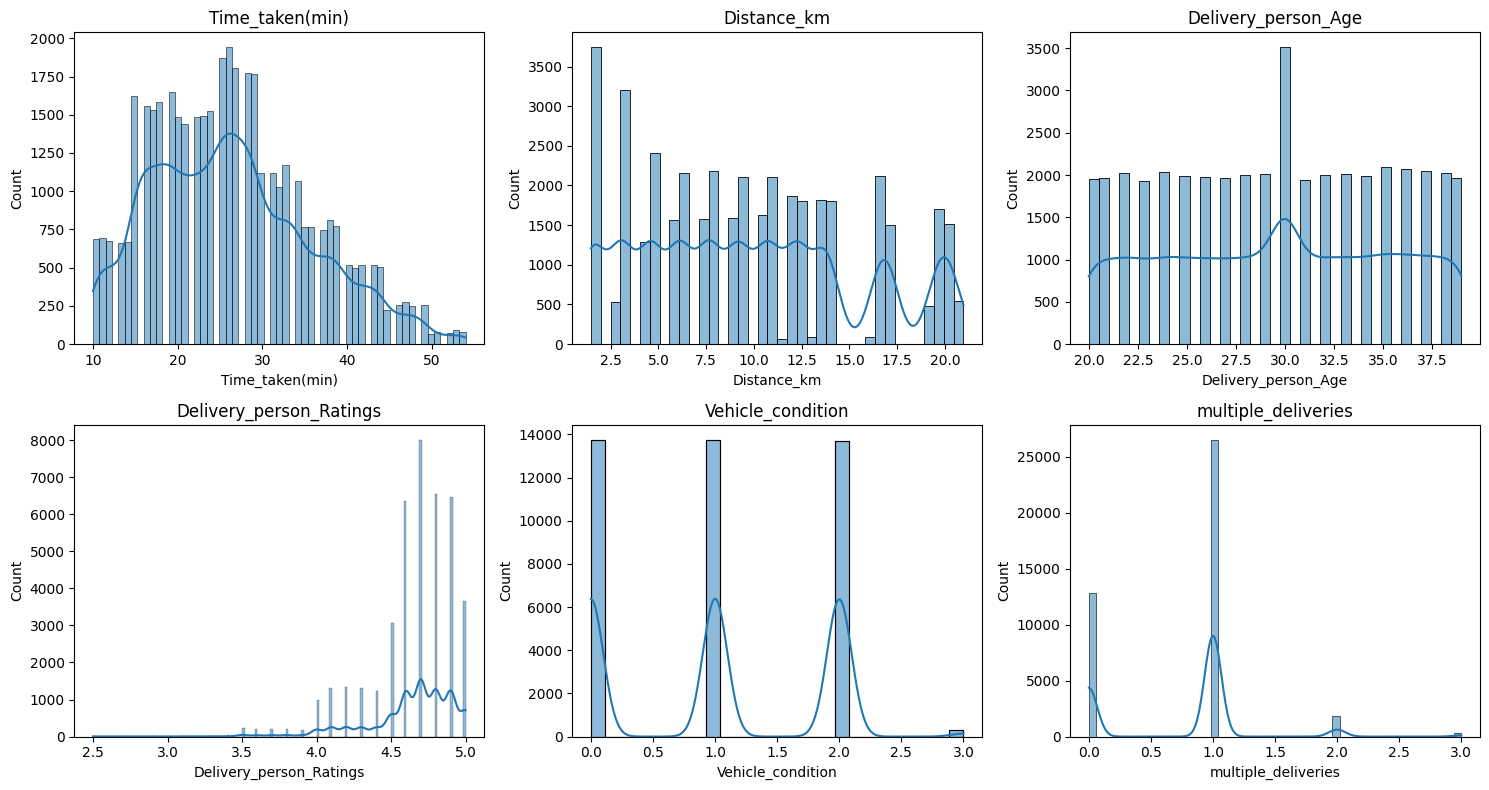

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_cols = ["Time_taken(min)", "Distance_km", "Delivery_person_Age",

             "Delivery_person_Ratings", "Vehicle_condition", "multiple_deliveries"]

for ax, c in zip(axes.flat, plot_cols):

    sns.histplot(df[c], kde=True, ax=ax)

    ax.set_title(c)

plt.tight_layout()

plt.show()

### 9. EDA — correlation heatmap

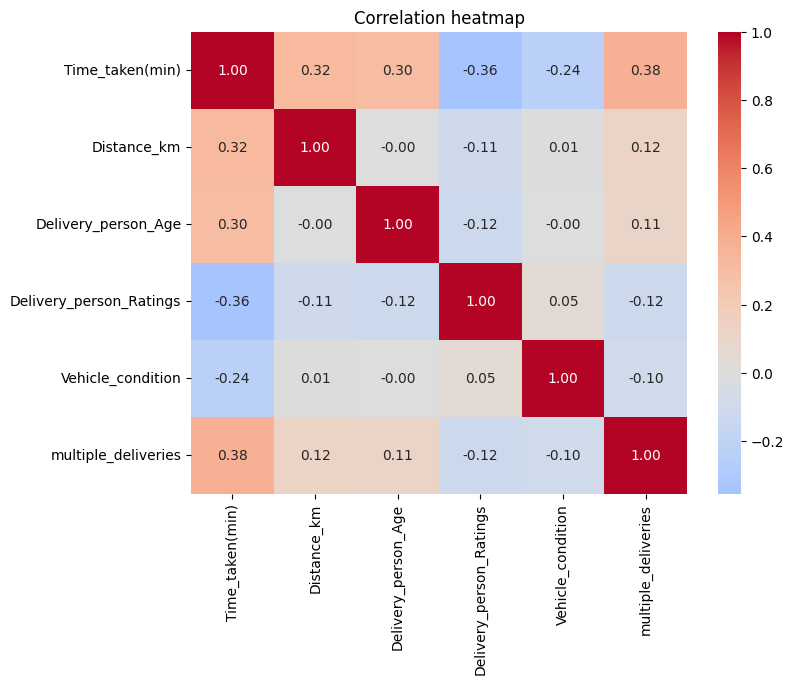

In [36]:
plt.figure(figsize=(8, 6))

num_predictors = ["Distance_km", "Delivery_person_Age", "Delivery_person_Ratings",

                   "Vehicle_condition", "multiple_deliveries"]

corr = df[["Time_taken(min)"] + num_predictors].corr()

sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")

plt.title("Correlation heatmap")

plt.show()

### 10. Train/test split

In [37]:
target = "Time_taken(min)"

X = df[num_predictors].copy()

X = pd.concat([

    X,

    pd.get_dummies(df["Road_traffic_density"], prefix="Traffic", drop_first=True),

    pd.get_dummies(df["Weatherconditions"], prefix="Weather", drop_first=True),

    pd.get_dummies(df["Festival"], prefix="Festival", drop_first=True),

    pd.get_dummies(df["City"], prefix="City", drop_first=True),

], axis=1)

y = df[target]



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((33178, 16), (8295, 16))

### 11. Baseline MLR (full model)

In [38]:
X_train_c = sm.add_constant(X_train)

baseline_model = sm.OLS(y_train, X_train_c.astype(float)).fit()

print(baseline_model.summary())

baseline_adj_r2 = baseline_model.rsquared_adj

print("Baseline Adj R2:", baseline_adj_r2)

                            OLS Regression Results                            
Dep. Variable:        Time_taken(min)   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     2952.
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        08:08:34   Log-Likelihood:            -1.0674e+05
No. Observations:               33178   AIC:                         2.135e+05
Df Residuals:                   33161   BIC:                         2.136e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

### 12. Outlier detection — Cook's Distance

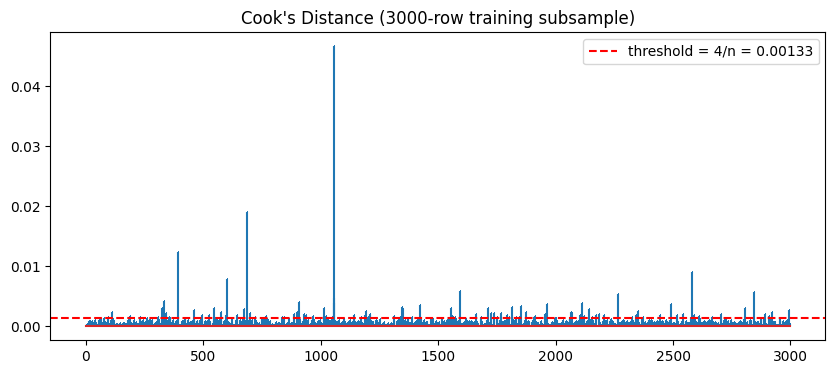

Points flagged by Cook's D: 120


In [39]:
# on a dataset this large, computing full leverage/influence for every row is

# expensive -- use a random subsample of the training set for outlier diagnostics

sample_idx = X_train.sample(n=3000, random_state=42).index

X_sample = X_train.loc[sample_idx]

y_sample = y_train.loc[sample_idx]

X_sample_c = sm.add_constant(X_sample)

sample_model = sm.OLS(y_sample, X_sample_c.astype(float)).fit()



influence = sample_model.get_influence()

cooks_d = influence.cooks_distance[0]



plt.figure(figsize=(10, 4))

plt.stem(cooks_d, markerfmt=",")

threshold = 4 / len(X_sample)

plt.axhline(threshold, color="red", linestyle="--", label=f"threshold = 4/n = {threshold:.5f}")

plt.title("Cook's Distance (3000-row training subsample)")

plt.legend()

plt.show()



cooks_flagged = np.where(cooks_d > threshold)[0]

print("Points flagged by Cook's D:", len(cooks_flagged))

### 13. Outlier detection — DFFITS

In [40]:
dffits, dffits_threshold = influence.dffits

dffits_cut = 2 * np.sqrt(X_sample_c.shape[1] / len(X_sample))



dffits_flagged = np.where(np.abs(dffits) > dffits_cut)[0]

print("Points flagged by DFFITS:", len(dffits_flagged))



both_flagged = np.intersect1d(cooks_flagged, dffits_flagged)

print("Flagged by both:", len(both_flagged))

Points flagged by DFFITS: 120
Flagged by both: 120


### 14. Drop influential points and refit

In [41]:
X_train_clean = X_sample.drop(X_sample.index[both_flagged])

y_train_clean = y_sample.drop(y_sample.index[both_flagged])



X_train_clean_c = sm.add_constant(X_train_clean)

model_no_outliers = sm.OLS(y_train_clean, X_train_clean_c.astype(float)).fit()



print("Adj R2 before (sample):", sample_model.rsquared_adj)

print("Adj R2 after removing influential points:", model_no_outliers.rsquared_adj)

Adj R2 before (sample): 0.5922922489551923
Adj R2 after removing influential points: 0.6358914960588956


### 15. Multicollinearity — VIF table

In [42]:
# cast to float first -- one-hot dummy columns are boolean by default in

# newer pandas, which breaks the linear algebra inside variance_inflation_factor

X_train_clean = X_train_clean.astype(float)



# VIF must be computed on a design matrix that includes the constant column,

# otherwise predictors that aren't centered near zero (like Age, roughly

# 15-50) get artificially inflated VIF -- this isn't real multicollinearity,

# it's a known statsmodels gotcha

X_vif = sm.add_constant(X_train_clean)

vif_df = pd.DataFrame()

vif_df["feature"] = X_vif.columns

vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_df = vif_df[vif_df["feature"] != "const"]  # constant's own VIF isn't meaningful, drop it from the view

vif_df.sort_values("VIF", ascending=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
6,Traffic_Jam,3.464463
7,Traffic_Low,3.175214
8,Traffic_Medium,3.064514
9,Weather_Fog,1.831631
10,Weather_Sandstorms,1.759505
13,Weather_Windy,1.753658
11,Weather_Stormy,1.743473
12,Weather_Sunny,1.686765
1,Distance_km,1.245817
5,multiple_deliveries,1.079979


### 16. PCA on the high-VIF feature block

In [43]:
high_vif_cols = vif_df[(vif_df["VIF"] > 10) & (vif_df["feature"].isin(num_predictors))]["feature"].tolist()

print("Combining into PCA:", high_vif_cols)



if len(high_vif_cols) >= 2:

    pca = PCA(n_components=2, random_state=42)

    pca_train = pca.fit_transform(X_train_clean[high_vif_cols])

    print("Explained variance ratio:", pca.explained_variance_ratio_)

else:

    print("Fewer than 2 features crossed VIF>10 -- PCA skipped, multicollinearity wasn't severe enough to need it")

Combining into PCA: []
Fewer than 2 features crossed VIF>10 -- PCA skipped, multicollinearity wasn't severe enough to need it


### 17. Rebuild feature set (with PCA components if used)

In [44]:
if len(high_vif_cols) >= 2:

    remaining_cols = [c for c in X_train_clean.columns if c not in high_vif_cols]

    X_train_pca = pd.concat([

        X_train_clean[remaining_cols].reset_index(drop=True),

        pd.DataFrame(pca_train, columns=["PC1", "PC2"])

    ], axis=1)

else:

    X_train_pca = X_train_clean.reset_index(drop=True)



y_train_clean = y_train_clean.reset_index(drop=True)

X_train_pca.head()

,Distance_km,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Traffic_Jam,Traffic_Low,Traffic_Medium,Weather_Fog,Weather_Sandstorms,Weather_Stormy,Weather_Sunny,Weather_Windy,Festival_Yes,City_Semi-Urban,City_Urban
0,3.059363,23.0,4.9,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16.635416,24.0,4.7,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.554506,27.0,4.9,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,16.606416,25.0,4.7,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.029525,34.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 18. Backward elimination

In [45]:
def backward_elimination(X, y, sig_level=0.05):

    X = sm.add_constant(X.astype(float))

    while True:

        model = sm.OLS(y, X).fit()

        pvals = model.pvalues.drop("const")

        worst_p = pvals.max()

        if worst_p > sig_level:

            worst_feature = pvals.idxmax()

            X = X.drop(columns=[worst_feature])

        else:

            break

    return model, X.columns.tolist()



be_model, be_features = backward_elimination(X_train_pca, y_train_clean)

print("Features kept:", be_features)

print("Adj R2 after backward elimination:", be_model.rsquared_adj)

Features kept: ['const', 'Distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'Traffic_Low', 'Traffic_Medium', 'Weather_Sandstorms', 'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy', 'Festival_Yes', 'City_Semi-Urban', 'City_Urban']
Adj R2 after backward elimination: 0.6357277803850883


### 19. Model comparison — AIC / BIC / Mallow's Cp / PRESS

In [46]:
def press_statistic(model):

    influence = model.get_influence()

    resid = model.resid

    leverage = influence.hat_matrix_diag

    press_resid = resid / (1 - leverage)

    return np.sum(press_resid ** 2)



def mallows_cp(model, full_model):

    n = model.nobs

    p = model.df_model + 1

    mse_full = full_model.mse_resid

    return (model.ssr / mse_full) - (n - 2 * p)



full_model_pca, _ = backward_elimination(X_train_pca, y_train_clean, sig_level=1.0)



comparison = pd.DataFrame({

    "model": ["full_model (all features)", "backward_elimination"],

    "adj_r2": [full_model_pca.rsquared_adj, be_model.rsquared_adj],

    "AIC": [full_model_pca.aic, be_model.aic],

    "BIC": [full_model_pca.bic, be_model.bic],

    "Mallows_Cp": [mallows_cp(full_model_pca, full_model_pca), mallows_cp(be_model, full_model_pca)],

    "PRESS": [press_statistic(full_model_pca), press_statistic(be_model)]

})

comparison

,model,adj_r2,AIC,BIC,Mallows_Cp,PRESS
0,full_model (all features),0.635891,17874.343210,17969.791939,16.000000,83564.855273
1,backward_elimination,0.635728,17873.648337,17957.165975,15.288652,83540.830029


### 20. Final model fit

In [47]:
final_model = be_model

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Time_taken(min)   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     387.5
Date:                Mon, 17 Aug 2026   Prob (F-statistic):               0.00
Time:                        08:08:47   Log-Likelihood:                -8922.8
No. Observations:                2880   AIC:                         1.787e+04
Df Residuals:                    2866   BIC:                         1.796e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


### 21. Assumption checks

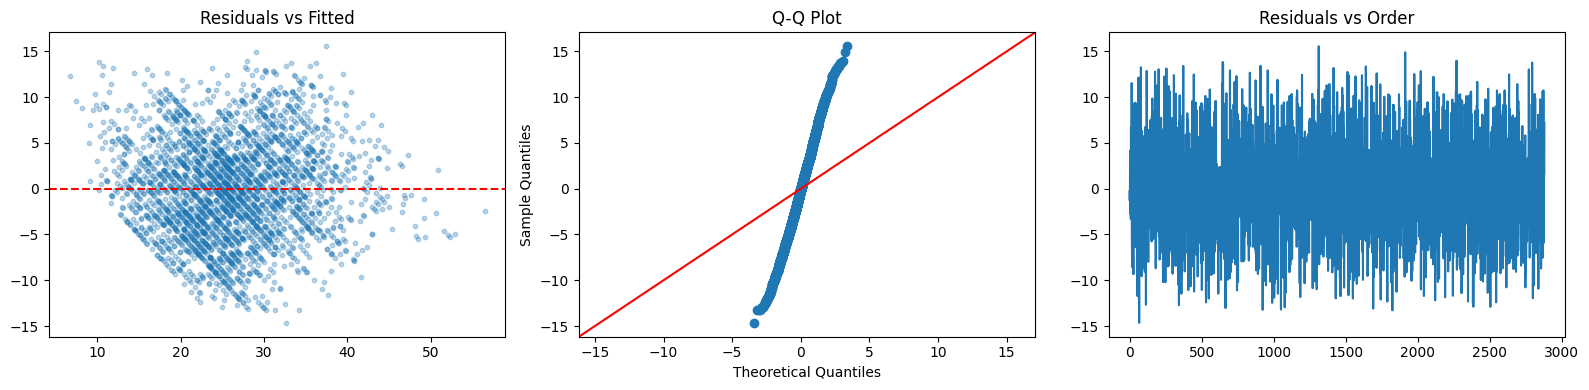

Shapiro-Wilk normality p-value: 8.021523032775475e-07
Durbin-Watson statistic: 1.9649326148160018


In [48]:
fitted = final_model.fittedvalues

resid = final_model.resid



fig, axes = plt.subplots(1, 3, figsize=(16, 4))



axes[0].scatter(fitted, resid, alpha=0.3, s=10)

axes[0].axhline(0, color="red", linestyle="--")

axes[0].set_title("Residuals vs Fitted")



sm.qqplot(resid, line="45", ax=axes[1])

axes[1].set_title("Q-Q Plot")



axes[2].plot(resid.values)

axes[2].set_title("Residuals vs Order")

plt.tight_layout()

plt.show()



print("Shapiro-Wilk normality p-value:", stats.shapiro(resid.sample(min(len(resid), 5000), random_state=42))[1])

print("Durbin-Watson statistic:", durbin_watson(resid))

### 22. Results summary

In [49]:
summary_table = pd.DataFrame({

    "stage": ["Baseline (sample, with outliers)", "Final (outliers removed, VIF/PCA, backward elimination)"],

    "Adj_R2": [sample_model.rsquared_adj, final_model.rsquared_adj],

    "n_features": [X_sample.shape[1], len(be_features) - 1]

})

summary_table

,stage,Adj_R2,n_features
0,"Baseline (sample, with outliers)",0.592292,16
1,"Final (outliers removed, VIF/PCA, backward eli...",0.635728,14


### 23. Sanity check on full training data (not just the 3000-row sample)

In [50]:
# refit the final selected features on the FULL training set to confirm the

# sample-based model selection holds up at full scale

final_features = [c for c in be_features if c != "const" and c in X_train.columns]

X_full_final = sm.add_constant(X_train[final_features].astype(float))

full_scale_model = sm.OLS(y_train, X_full_final).fit()

print("Adj R2 on full training data with selected features:", full_scale_model.rsquared_adj)

Adj R2 on full training data with selected features: 0.5870530879305279


### 24. Save results

In [51]:
summary_table.to_csv("mlr_results_summary.csv", index=False)

comparison.to_csv("model_comparison_aic_bic_cp_press.csv", index=False)

print("Saved results CSVs")

Saved results CSVs


# Part 2 — ML & DL Model Comparison + Delay Explanation Agent

The MLR pipeline above is the core statistical analysis (outliers,
multicollinearity, model selection, assumptions). This second part compares
it against standard ML/DL regressors on the full cleaned dataset, then builds
a simple agent that explains *why* a specific delivery is predicted to take
as long as it does.

### 25. Prepare features for ML models (full cleaned data, not the outlier-diagnostic sample)

In [52]:
# MLR needed a small sample for exact Cook's D/DFFITS computation -- ML models
# don't have that constraint, so they train on the full cleaned dataset
X_ml = df[num_predictors].copy()
X_ml = pd.concat([
    X_ml,
    pd.get_dummies(df["Road_traffic_density"], prefix="Traffic", drop_first=True),
    pd.get_dummies(df["Weatherconditions"], prefix="Weather", drop_first=True),
    pd.get_dummies(df["Festival"], prefix="Festival", drop_first=True),
    pd.get_dummies(df["City"], prefix="City", drop_first=True),
], axis=1).astype(float)
y_ml = df["Time_taken(min)"]

print(X_ml.shape)

(41473, 16)


### 26. Train/test split for ML models

In [53]:
X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)
X_ml_train.shape, X_ml_test.shape

((33178, 16), (8295, 16))

### 27. Metrics helper

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

results = []

def evaluate(name, model, X_test, y_test, preds):
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    results.append({"model": name, "R2": r2, "MAE": mae, "RMSE": rmse})
    print(f"{name}: R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")

### 28. Linear Regression (baseline)

In [55]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lin_reg = LinearRegression()
lin_reg.fit(X_ml_train, y_ml_train)
evaluate("Linear Regression", lin_reg, X_ml_test, y_ml_test, lin_reg.predict(X_ml_test))

Linear Regression: R2=0.586  MAE=4.78  RMSE=5.98


### 29. Ridge & Lasso

In [56]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_ml_train, y_ml_train)
evaluate("Ridge", ridge, X_ml_test, y_ml_test, ridge.predict(X_ml_test))

lasso = Lasso(alpha=0.1)
lasso.fit(X_ml_train, y_ml_train)
evaluate("Lasso", lasso, X_ml_test, y_ml_test, lasso.predict(X_ml_test))

Ridge: R2=0.586  MAE=4.78  RMSE=5.98
Lasso: R2=0.566  MAE=4.87  RMSE=6.13


### 30. Random Forest Regressor

In [57]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_ml_train, y_ml_train)
evaluate("Random Forest", rf, X_ml_test, y_ml_test, rf.predict(X_ml_test))

Random Forest: R2=0.821  MAE=3.13  RMSE=3.94


### 31. Gradient Boosting Regressor

In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb.fit(X_ml_train, y_ml_train)
evaluate("Gradient Boosting", gb, X_ml_test, y_ml_test, gb.predict(X_ml_test))

Gradient Boosting: R2=0.802  MAE=3.31  RMSE=4.14


### 32. XGBoost Regressor

In [59]:
!pip install xgboost -q
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb.fit(X_ml_train, y_ml_train)
evaluate("XGBoost", xgb, X_ml_test, y_ml_test, xgb.predict(X_ml_test))

XGBoost: R2=0.825  MAE=3.10  RMSE=3.89


### 33. CatBoost Regressor

In [60]:
!pip install catboost -q
from catboost import CatBoostRegressor

catb = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1, random_state=42, verbose=0)
catb.fit(X_ml_train, y_ml_train)
evaluate("CatBoost", catb, X_ml_test, y_ml_test, catb.predict(X_ml_test))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
CatBoost: R2=0.824  MAE=3.11  RMSE=3.91


### 34. LightGBM Regressor

In [61]:
!pip install lightgbm -q
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)
lgbm.fit(X_ml_train, y_ml_train)
evaluate("LightGBM", lgbm, X_ml_test, y_ml_test, lgbm.predict(X_ml_test))

LightGBM: R2=0.826  MAE=3.09  RMSE=3.89


### 35. Simple Deep Learning model (Feedforward Neural Network)

In [62]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# NN needs scaled inputs, unlike the tree models above
scaler = StandardScaler()
X_dl_train = scaler.fit_transform(X_ml_train)
X_dl_test = scaler.transform(X_ml_test)

dl_model = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=(X_dl_train.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(16, activation="relu"),
    keras.layers.Dense(1)
])
dl_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = dl_model.fit(X_dl_train, y_ml_train, validation_split=0.1,
                        epochs=50, batch_size=64, verbose=0)

dl_preds = dl_model.predict(X_dl_test, verbose=0).flatten()
evaluate("Neural Network", dl_model, X_dl_test, y_ml_test, dl_preds)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network: R2=0.814  MAE=3.19  RMSE=4.01


### 36. Model comparison — MLR vs ML vs DL

In [63]:
# add the classical MLR final model's test-set performance for a fair comparison
mlr_test_features = [c for c in final_features if c in X_ml_test.columns]
mlr_test_c = sm.add_constant(X_ml_test[mlr_test_features].astype(float))
# align columns to the fitted model's expected order
mlr_test_c = mlr_test_c[full_scale_model.params.index]
mlr_preds = full_scale_model.predict(mlr_test_c)
evaluate("Classical MLR (final)", full_scale_model, X_ml_test, y_ml_test, mlr_preds)

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

Classical MLR (final): R2=0.586  MAE=4.78  RMSE=5.98


,model,R2,MAE,RMSE
0,LightGBM,0.825538,3.093031,3.885190
1,XGBoost,0.825025,3.100677,3.890903
2,CatBoost,0.823626,3.112122,3.906427
3,Random Forest,0.820568,3.128013,3.940145
4,Neural Network,0.814081,3.186706,4.010735
5,Gradient Boosting,0.802071,3.308529,4.138247
6,Ridge,0.586128,4.783166,5.984047
7,Linear Regression,0.586117,4.783188,5.984125
8,Classical MLR (final),0.586015,4.784387,5.984864
9,Lasso,0.565589,4.872700,6.130730


### 37. SHAP explainability on the best model

Explaining: LightGBM


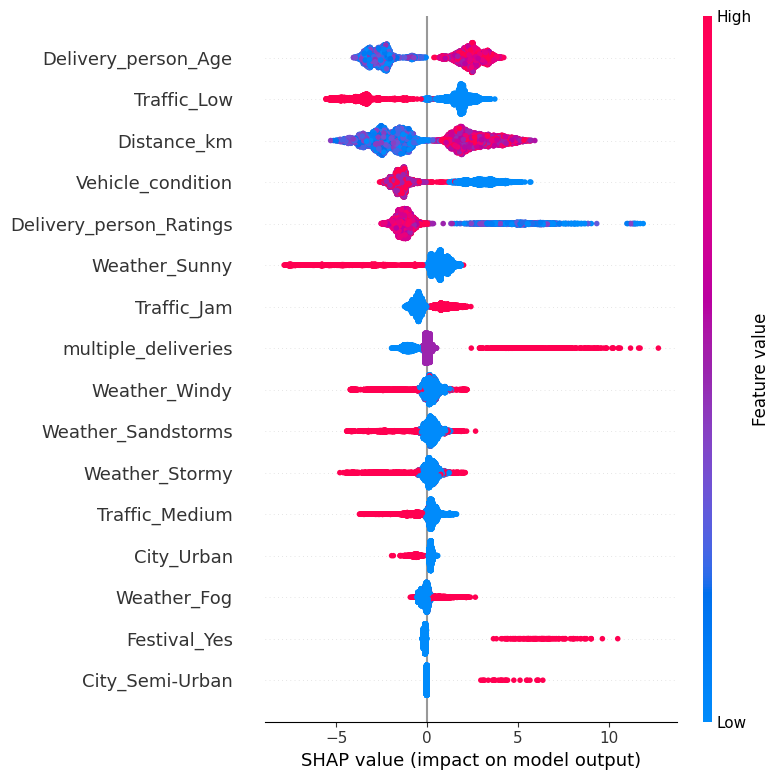

In [64]:
!pip install shap -q
import shap

# pick whichever boosting model scored best (typically XGBoost/CatBoost/LightGBM)
best_model_name = results_df.iloc[0]["model"]
model_lookup = {"XGBoost": xgb, "CatBoost": catb, "LightGBM": lgbm,
                 "Random Forest": rf, "Gradient Boosting": gb}
best_model = model_lookup.get(best_model_name, xgb)  # default to xgb if best was MLR/linear/NN
print("Explaining:", best_model_name if best_model_name in model_lookup else "XGBoost (fallback, best model wasn't tree-based)")

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_ml_test)

shap.summary_plot(shap_values, X_ml_test, show=True)

### 38. Delay Explanation Agent

In [65]:
# Rule-based explanation from SHAP values -- always works, no external model needed.
# Takes one test-set order and explains which features pushed the predicted
# time up or down the most, in plain English.

def explain_delivery(row_index, top_n=3):
    row = X_ml_test.iloc[[row_index]]
    pred = best_model.predict(row)[0]
    row_shap = explainer.shap_values(row)[0]

    contributions = pd.Series(row_shap, index=row.columns).sort_values(key=abs, ascending=False)
    top_features = contributions.head(top_n)

    lines = [f"Predicted delivery time: {pred:.1f} minutes."]
    for feat, val in top_features.items():
        direction = "increased" if val > 0 else "decreased"
        lines.append(f" - {feat} {direction} the estimate by {abs(val):.1f} min (value: {row[feat].values[0]:.2f})")
    return "\n".join(lines)

print(explain_delivery(0))

Predicted delivery time: 30.6 minutes.
 - Weather_Sunny decreased the estimate by 7.5 min (value: 1.00)
 - Vehicle_condition increased the estimate by 4.1 min (value: 0.00)
 - Delivery_person_Age increased the estimate by 2.9 min (value: 36.00)


### 39. Try the agent on a few sample orders

In [66]:
for i in [0, 5, 20]:
    print(f"--- Order {i} ---")
    print(explain_delivery(i))
    print()

--- Order 0 ---
Predicted delivery time: 30.6 minutes.
 - Weather_Sunny decreased the estimate by 7.5 min (value: 1.00)
 - Vehicle_condition increased the estimate by 4.1 min (value: 0.00)
 - Delivery_person_Age increased the estimate by 2.9 min (value: 36.00)

--- Order 5 ---
Predicted delivery time: 13.7 minutes.
 - Traffic_Low decreased the estimate by 3.5 min (value: 1.00)
 - Weather_Sandstorms decreased the estimate by 3.1 min (value: 1.00)
 - Delivery_person_Age decreased the estimate by 2.8 min (value: 25.00)

--- Order 20 ---
Predicted delivery time: 17.7 minutes.
 - Distance_km decreased the estimate by 3.4 min (value: 5.96)
 - Traffic_Medium decreased the estimate by 2.2 min (value: 1.00)
 - Traffic_Low increased the estimate by 1.9 min (value: 0.00)



### 40. Optional — rephrase the explanation naturally with a small local LLM

In [67]:
# Same model family as the Financial Research Assistant project (Qwen2.5),
# used here just to turn the rule-based explanation into a natural sentence.
# This step is optional and needs a GPU runtime -- skip it if running on CPU.

!pip install transformers accelerate -q
from transformers import pipeline

llm = pipeline("text-generation", model="Qwen/Qwen2.5-3B-Instruct",
               device_map="auto", torch_dtype="auto")

def explain_delivery_natural(row_index, top_n=3):
    raw_explanation = explain_delivery(row_index, top_n)
    prompt = (
        "Rewrite this delivery time explanation as one short, natural sentence "
        "for a customer. Keep it factual, don't invent numbers not given.\n\n"
        + raw_explanation
    )
    messages = [{"role": "user", "content": prompt}]
    output = llm(messages, max_new_tokens=80, do_sample=False)
    return output[0]["generated_text"][-1]["content"]

print(explain_delivery_natural(0))

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


The predicted delivery time of 30.6 minutes was adjusted due to weather conditions (Sunny, reducing the estimate by 7.5 minutes) and vehicle condition (increasing the estimate by 4.1 minutes), with the final adjustment influenced by the delivery person's age (36 years old, increasing the estimate by 2.9 minutes).


In [68]:
import joblib

# save whichever tree model was best -- the Streamlit app loads this file directly
joblib.dump(best_model, "best_model.pkl")
joblib.dump(list(X_ml_train.columns), "feature_columns.pkl")
print("Saved best_model.pkl and feature_columns.pkl -- download these two files")
print("(Colab: use the file browser on the left, right-click each file -> Download)")

Saved best_model.pkl and feature_columns.pkl -- download these two files
(Colab: use the file browser on the left, right-click each file -> Download)
